In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import symlib
import numpy as np
import matplotlib.cm as cm
import matplotlib.colors as colors
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
from matplotlib.lines import Line2D
import warnings; warnings.simplefilter('ignore')
import sys
import h5py
import pandas as pd
import seaborn as sns
sys.path.insert(0, '/Users/jsmonzon/Research/SatGen/mcmc/src/')
import jsm_ancillary
import jsm_visualize
import jsm_SHMR
import jsm_mcmc
import jsm_stats
import jsm_models
import evolve as ev
import galhalo as gh
import profiles as profiles
import config as cfg

In [3]:
plt.style.use('../../../SatGen/notebooks/paper1/paper.mplstyle')
double_textwidth = 7.0 #inches
single_textwidth = 3.5 #inches
levelz = [1-0.99, 1-0.95, 1-0.68]

### claude written code

In [4]:
class Symphony_SubhaloCounter:
    """
    Measure subhalo statistics above a mass threshold within R_vir
    for each host halo in a symlib simulation suite.

    Parameters
    ----------
    base_dir       : base directory of the simulation suite (str)
    suite_name     : name of the simulation suite (str)
    mass_threshold : minimum subhalo mass to count (float, default 1e9 M_sun)

    Attributes
    ----------
    df : pandas DataFrame with columns:
        logMvir   - log10 host virial mass at z=0
        log1pz50  - log10(1 + z_50), where z_50 is the half-mass redshift
        logc      - log10 host concentration at z=0
        logMs     - log10 mass of most massive surviving subhalo within R_vir
        logNsub   - log10 number of subhalos within R_vir above threshold
        logfsub   - log10 subhalo mass fraction (Ms_tot / Mvir)
    """

    def __init__(self, base_dir, suite_name, mass_threshold):
        self.base_dir        = base_dir
        self.suite_name      = suite_name
        self.mass_threshold  = mass_threshold
        self.n_hosts         = symlib.n_hosts(suite_name)

        self.df = self._build()

    # ------------------------------------------------------------------
    # Internal helpers
    # ------------------------------------------------------------------
    def _find_nearest(self, array, value):
        return (np.abs(array - value)).argmin()

    def _process_host(self, i_host):
        """
        Process a single host halo and return a dict of statistics,
        or None if the host should be skipped.
        """
        sim_dir = symlib.get_host_directory(self.base_dir, self.suite_name, i_host)

        r, hist  = symlib.read_rockstar(sim_dir)
        s, hist  = symlib.read_symfind(sim_dir)

        h, hist2 = symlib.read_subhalos(sim_dir)
        scale    = symlib.scale_factors(sim_dir)

        # ------------------------------------------------------------------
        # Host halo properties
        # ------------------------------------------------------------------
        ok_host   = r[0, :]["ok"]
        a         = scale[ok_host]
        Mhost     = r[0, ok_host]["m"]
        Mhost_z0  = Mhost[-1]
        chost_z0  = r[0, ok_host]["cvir"][-1]
        host_rvir = r[0, -1]["rvir"]

        # half-mass redshift z50
        a50 = a[self._find_nearest(Mhost, Mhost_z0 / 2)]
        z50 = 1. / a50 - 1.

        # ------------------------------------------------------------------
        # Subhalo selection: within R_vir, alive at z=0, above mass threshold
        # ------------------------------------------------------------------
        sub_x = h[:, -1]["x"]
        r_3d  = np.sqrt(np.sum(sub_x**2, axis=1))
        ok    = h["ok"][:, -1]

        msub_all = np.array([r[i, -1]["m"] for i in range(1, len(r))])

        within_rvir  = r_3d[1:] < host_rvir
        above_thresh = msub_all > self.mass_threshold
        ok_subs      = ok[1:] & within_rvir & above_thresh

        msub_selected = msub_all[ok_subs]

        MMs  = np.max(msub_selected)
        M_sub  = np.sum(msub_selected)
        f_sub  = M_sub / Mhost_z0
        N_sub = len(msub_selected)

        if MMs < self.mass_threshold:
            MMs = 0
            f_sub = 0
            N_sub = 0

        return {
        "logMvir":  np.log10(Mhost_z0),
        "log1pz50": np.log10(1 + z50),
        "logc":     np.log10(chost_z0),
        "Nsub":     N_sub,
        "logNsub":  np.log10(N_sub),
        "fsub":     f_sub,
        "logfsub":  np.log10(f_sub),
        "MMs":   MMs / Mhost_z0,
        "logMMs":   np.log10(MMs / Mhost_z0)}
    

    def _build(self):
        """Loop over all hosts and collect results into a DataFrame."""
        rows = []
        for i_host in range(self.n_hosts):
            try:
                row = self._process_host(i_host)
                if row is not None:
                    rows.append(row)
            except Exception as e:
                print(f"Error processing i_host={i_host}: {e}")
                continue

        return pd.DataFrame(rows, columns=['logMvir', 'log1pz50', 'logc',
                                           'Nsub', 'logNsub',
                                           'fsub', 'logfsub',
                                           'MMs', 'logMMs']).replace([np.inf, -np.inf], np.nan)


In [88]:
mass_thrs = np.array([1.77827941e+09, 3.16227766e+09, 5.62341325e+09])

In [160]:
sym_300 = Symphony_SubhaloCounter("/Users/jsmonzon/Research/Misc/Symphony/", "SymphonyMilkyWay", mass_thrs[0])

sym_500 = Symphony_SubhaloCounter("/Users/jsmonzon/Research/Misc/Symphony/", "SymphonyMilkyWay", mass_thrs[1])

sym_1000 = Symphony_SubhaloCounter("/Users/jsmonzon/Research/Misc/Symphony/", "SymphonyMilkyWay", mass_thrs[2])

Error processing i_host=4: zero-size array to reduction operation maximum which has no identity
Error processing i_host=5: zero-size array to reduction operation maximum which has no identity
Error processing i_host=4: zero-size array to reduction operation maximum which has no identity
Error processing i_host=5: zero-size array to reduction operation maximum which has no identity
Error processing i_host=7: zero-size array to reduction operation maximum which has no identity
Error processing i_host=8: zero-size array to reduction operation maximum which has no identity
Error processing i_host=26: zero-size array to reduction operation maximum which has no identity
Error processing i_host=4: zero-size array to reduction operation maximum which has no identity
Error processing i_host=5: zero-size array to reduction operation maximum which has no identity
Error processing i_host=7: zero-size array to reduction operation maximum which has no identity
Error processing i_host=8: zero-size ar

In [171]:
sym_300 = Symphony_SubhaloCounter("/Users/jsmonzon/Research/Misc/Symphony/", "SymphonyMilkyWay", 1e9)


In [161]:
# S0_1000 = jsm_ancillary.load_sample("../../data/MW/S0_1000.h5")[0:45]
# S0_500 = jsm_ancillary.load_sample("../../data/MW/S0_500.h5")[0:45]
# S0_300 = jsm_ancillary.load_sample("../../data/MW/S0_fid.h5")[0:45]

# S0_1000_clean = jsm_ancillary.clean_sample(S0_1000, "withering", 1000*((1.2*10**8)/300))
# S0_500_clean = jsm_ancillary.clean_sample(S0_500, "withering", 500*((1.2*10**8)/300))
# S0_fid_clean = jsm_ancillary.clean_sample(S0_300, "withering", 1.2*10**8)

# sns.kdeplot(S0_1000_clean.Nsub)
# sns.kdeplot(S0_500_clean.Nsub)
# sns.kdeplot(S0_fid_clean.Nsub)

# plt.xlim(0, 140)

In [162]:
sym_rhoz_1000, sym_rho_errz_1000, _ = jsm_stats.jackknife_correlation(sym_1000.df["log1pz50"], sym_1000.df["Nsub"])

sym_rhoc_1000, sym_rho_errc_1000, _ = jsm_stats.jackknife_correlation(sym_1000.df["logc"], sym_1000.df["Nsub"])

sym_rhom_1000, sym_rho_errm_1000, _ = jsm_stats.jackknife_correlation(sym_1000.df["MMs"], sym_1000.df["Nsub"])

In [163]:
sym_rhoz_500, sym_rho_errz_500, _ = jsm_stats.jackknife_correlation(sym_500.df["log1pz50"], sym_500.df["Nsub"])

sym_rhoc_500, sym_rho_errc_500, _ = jsm_stats.jackknife_correlation(sym_500.df["logc"], sym_500.df["Nsub"])

sym_rhom_500, sym_rho_errm_500, _ = jsm_stats.jackknife_correlation(sym_500.df["MMs"], sym_500.df["Nsub"])


In [172]:
sym_rhoz_300, sym_rho_errz_300, _ = jsm_stats.jackknife_correlation(sym_300.df["log1pz50"], sym_300.df["Nsub"])

sym_rhoc_300, sym_rho_errc_300, _ = jsm_stats.jackknife_correlation(sym_300.df["logc"], sym_300.df["Nsub"])

sym_rhom_300, sym_rho_errm_300, _ = jsm_stats.jackknife_correlation(sym_300.df["MMs"], sym_300.df["Nsub"])

In [175]:
sym_rhom_300

0.6003281884810586

In [165]:
S0_300f = jsm_ancillary.load_sample("../../data/MW/S0_fid.h5")
S0_500f = jsm_ancillary.load_sample("../../data/MW/S0_500.h5")
S0_1000f = jsm_ancillary.load_sample("../../data/MW/S0_1000.h5")

In [167]:
S0_300 = jsm_ancillary.clean_sample(S0_300f, "artificial", mass_thrs[0])[0:45]
S0_500 = jsm_ancillary.clean_sample(S0_300f, "artificial", mass_thrs[1])[0:45]
S0_1000 = jsm_ancillary.clean_sample(S0_300f, "artificial", mass_thrs[2])[0:45]

In [168]:
S0_1000["Nsub"] == S0_300["Nsub"]

0       True
1       True
10      True
100     True
1000    True
1001    True
1002    True
1003    True
1004    True
1005    True
1006    True
1007    True
1008    True
1009    True
101     True
1010    True
1011    True
1012    True
1013    True
1014    True
1015    True
1016    True
1017    True
1018    True
1019    True
102     True
1020    True
1021    True
1022    True
1023    True
1024    True
1025    True
1026    True
1027    True
1028    True
1029    True
103     True
1030    True
1031    True
1032    True
1033    True
1034    True
1035    True
1036    True
1037    True
Name: Nsub, dtype: bool

In [169]:
S0_300["Nsub"]

0        9.0
1       13.0
10       8.0
100      8.0
1000     4.0
1001     1.0
1002    11.0
1003     4.0
1004     5.0
1005     8.0
1006     4.0
1007    10.0
1008    14.0
1009     7.0
101      5.0
1010     4.0
1011     6.0
1012    12.0
1013     7.0
1014     6.0
1015     8.0
1016     6.0
1017    10.0
1018     9.0
1019     9.0
102      9.0
1020     9.0
1021     2.0
1022     9.0
1023    11.0
1024     7.0
1025    12.0
1026     8.0
1027     6.0
1028     6.0
1029     5.0
103      6.0
1030     6.0
1031    10.0
1032     8.0
1033     8.0
1034     6.0
1035     9.0
1036     6.0
1037     7.0
Name: Nsub, dtype: float64

(0.0, 18.90427827218649)

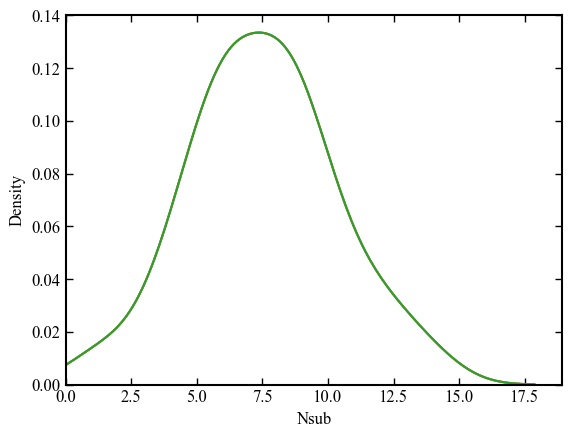

In [170]:
sns.kdeplot(S0_1000.Nsub)
sns.kdeplot(S0_500.Nsub)
sns.kdeplot(S0_300.Nsub)
plt.xlim(0)

In [125]:
S0_rhoz_1000, S0_rho_errz_1000, _ = jsm_stats.jackknife_correlation(S0_1000["log1pz50"], S0_1000["Nsub"])

S0_rhoc_1000, S0_rho_errc_1000, _ = jsm_stats.jackknife_correlation(S0_1000["logc"], S0_1000["Nsub"])

S0_rhom_1000, S0_rho_errm_1000, _ = jsm_stats.jackknife_correlation(S0_1000["MMs"], S0_1000["Nsub"])

In [126]:
S0_rhoz_500, S0_rho_errz_500, _ = jsm_stats.jackknife_correlation(S0_500["log1pz50"], S0_500["Nsub"])

S0_rhoc_500, S0_rho_errc_500, _ = jsm_stats.jackknife_correlation(S0_500["logc"], S0_500["Nsub"])

S0_rhom_500, S0_rho_errm_500, _ = jsm_stats.jackknife_correlation(S0_500["MMs"], S0_500["Nsub"])

In [127]:
S0_rhoz_300, S0_rho_errz_300, _ = jsm_stats.jackknife_correlation(S0_300["log1pz50"], S0_300["Nsub"])

S0_rhoc_300, S0_rho_errc_300, _ = jsm_stats.jackknife_correlation(S0_300["logc"], S0_300["Nsub"])

S0_rhom_300, S0_rho_errm_300, _ = jsm_stats.jackknife_correlation(S0_300["MMs"], S0_300["Nsub"])

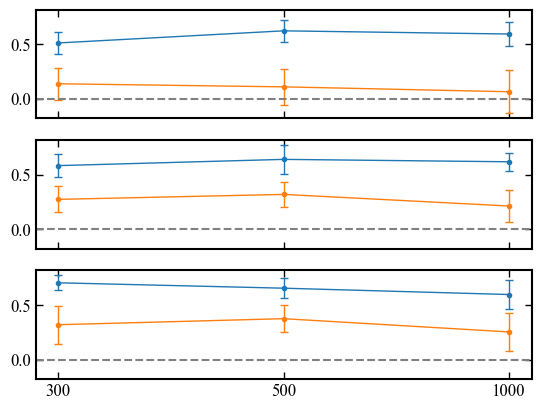

In [128]:
fig, ax = plt.subplots(3, 1, sharex=True, sharey=True)

dummy = [1,2,3]

ax[0].errorbar(dummy, np.abs([sym_rhoz_300, sym_rhoz_500, sym_rhoz_1000]), yerr = [sym_rho_errz_300, sym_rho_errz_500, sym_rho_errz_1000], marker=".", capsize=3, lw=1)

ax[1].errorbar(dummy, np.abs([sym_rhoc_300, sym_rhoc_500, sym_rhoc_1000]), yerr = [sym_rho_errc_300, sym_rho_errc_500, sym_rho_errc_1000], marker=".", capsize=3, lw=1)

ax[2].errorbar(dummy, [sym_rhom_300, sym_rhom_500, sym_rhom_1000], yerr = [sym_rho_errm_300, sym_rho_errm_500, sym_rho_errm_1000], marker=".", capsize=3, lw=1)

ax[0].errorbar(dummy, np.abs([S0_rhoz_300, S0_rhoz_500, S0_rhoz_1000]), yerr = [S0_rho_errz_300, S0_rho_errz_500, S0_rho_errz_1000], marker=".", capsize=3, lw=1)

ax[1].errorbar(dummy, np.abs([S0_rhoc_300, S0_rhoc_500, S0_rhoc_1000]), yerr = [S0_rho_errc_300, S0_rho_errc_500, S0_rho_errc_1000], marker=".", capsize=3, lw=1)

ax[2].errorbar(dummy, [S0_rhom_300, S0_rhom_500, S0_rhom_1000], yerr = [S0_rho_errm_300, S0_rho_errm_500, S0_rho_errm_1000], marker=".", capsize=3, lw=1)


ax[2].set_xticks(dummy)
ax[2].set_xticklabels(["300", "500", "1000"])

for x in ax.flatten():
    x.axhline(0, ls="--", color="grey")


plt.show()

In [46]:
# binz = np.linspace(11.3, 12.7, 25)
# # --- Helper to plot hist + outline ---
# def hist_with_outline(data, color, label=None):
#     # filled histogram
#     ax.hist(
#         data,
#         bins=binz,
#         edgecolor="white",
#         alpha=0.3,
#         color=color,
#         density=True,
#         label=label
#     )
    
#     # outline using numpy histogram
#     counts, edges = np.histogram(data, bins=binz, density=True)
#     centers = 0.5 * (edges[1:] + edges[:-1])
    
#     ax.step(centers, counts, where="mid", color=color, linewidth=1.5)

# fig, ax = plt.subplots(figsize=(single_textwidth, single_textwidth))

# # --- Plot datasets ---
# hist_with_outline(S0_clean.sample(45)["logMvir"],  "green", label="$S_0$")
# hist_with_outline(S15_clean.sample(45)["logMvir"], "darkorange", label="$S_{15}$")
# hist_with_outline(S30_clean.sample(45)["logMvir"], "red", label="$S_{30}$")


# # KDE
# sns.kdeplot(test_500.df["logMvir"], ax=ax, color="brown", label="Symphony")

# # Formatting
# ax.set_xlabel("log M$_{\\rm vir}$ [M$_{\\odot}$/h]")
# ax.set_ylabel("PDF")
# ax.legend(fontsize=11, framealpha=1)

# plt.tight_layout()
# plt.show()

In [12]:
# SHR = jsm_ancillary.load_sample("../../../StellarHalo/data/fiducial/S0HR_sample.h5")
# SLR = jsm_ancillary.load_sample("../../../StellarHalo/data/fiducial/S0_sample.h5")

In [13]:
# def short(sample, mass_res):

#     final_mass = jsm_ancillary.make_matrix(sample, "sat_mass")
#     final_rmag = jsm_ancillary.make_matrix(sample, "sat_final_rmag")


#     try:
#         host_rvir = jsm_ancillary.make_matrix(sample, "host_Rvir")[:, 0]
#     except TypeError:
#         host_rvir = sample["host_Rvir"].values
        
#     z50 = np.log10(1 + sample["host_z50"].values)

#     # Apply Rvir mask using the final (0th index) host Rvir per host
#     rvir_mask = final_rmag <= host_rvir[:, np.newaxis]
#     final_mass = np.where(rvir_mask, final_mass, np.nan)
#     Nsub = np.sum(final_mass > mass_res, axis=1)

#     return Nsub

In [14]:
# # sns.kdeplot(short(SLR, 1e8), c="C0")
# sns.kdeplot(short(SLR, 3e8), c="C1")
# sns.kdeplot(short(SLR, 7e8), c="C2")
# sns.kdeplot(short(SLR, 1e9), c="C3")
# sns.kdeplot(short(SLR, 2e9), c="C4")

# # sns.kdeplot(short(SHR, 1e8), ls="--", c="C0")
# sns.kdeplot(short(SHR, 3e8), ls="--", c="C1")
# sns.kdeplot(short(SHR, 7e8), ls="--", c="C2")
# sns.kdeplot(short(SHR, 1e9), ls="--", c="C3")
# sns.kdeplot(short(SHR, 2e9), ls="--", c="C4")